# Dataset Validation Pipeline
## Adapted for SVM Decision-Function Grading

This notebook validates whether your extracted features are suitable for the
**SVM decision-function grading pipeline**.

It runs 6 checks:
1. PCA separability — are fresh/rotten visually separable in 2D?
2. Covariance stability — is the covariance matrix well-conditioned?
3. SVM margin distribution — does the decision function separate classes?
4. Score distribution + Delta — are normalized scores well-separated?
5. Intra-class spread — does the score produce a continuous, non-collapsed output?
6. Per-vegetable separation — does each vegetable type have good separation?

**If 3+ checks fail → your features are not suitable for this grading pipeline.**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

## Load Features

We load the pre-extracted features from the `Features/` directory.
These are the 1312-dim vectors (EfficientNetB0 + handcrafted) produced by
`extract_dataset_features.py`.

In [2]:
# -------------------------------------------------------
# LOAD FEATURES
# Adjust the path if your Features/ folder is elsewhere
# -------------------------------------------------------

FEATURE_DIR = "../Features"   # relative to this notebook

X       = np.load(os.path.join(FEATURE_DIR, "X.npy"))
y_fresh = np.load(os.path.join(FEATURE_DIR, "y_fresh.npy")).astype(int)  # 1=fresh, 0=rotten
y_veg   = np.load(os.path.join(FEATURE_DIR, "y_veg.npy"))                # vegetable name strings

print("X shape         :", X.shape)
print("y_fresh shape   :", y_fresh.shape)
print("y_veg shape     :", y_veg.shape)
print("Unique vegetables:", np.unique(y_veg))
print("Fresh count     :", (y_fresh == 1).sum())
print("Rotten count    :", (y_fresh == 0).sum())

X shape         : (12642, 1312)
y_fresh shape   : (12642,)
y_veg shape     : (12642,)
Unique vegetables: ['apple' 'banana' 'capsicum' 'cucumber' 'potato']
Fresh count     : 6074
Rotten count    : 6568


## Train / Test Split + Scaling

Mirroring the exact preprocessing pipeline from `train_svm.py`:
stratified split by combined `veg_fresh` label, then StandardScaler fit on train only.

In [3]:
# Combined stratify label (same as train_split.py)
stratify_labels = np.array([f"{v}_{f}" for v, f in zip(y_veg, y_fresh)])

idx = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, stratify=stratify_labels, random_state=42
)

X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y_fresh[train_idx]
y_test  = y_fresh[test_idx]
veg_train = y_veg[train_idx]
veg_test  = y_veg[test_idx]

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

Train: 10113 | Test: 2529


## Check 1 — PCA Separability

Project scaled train features to 2D with PCA.
If fresh and rotten form visually distinct clusters → the feature space is
separable and the grading pipeline is appropriate.

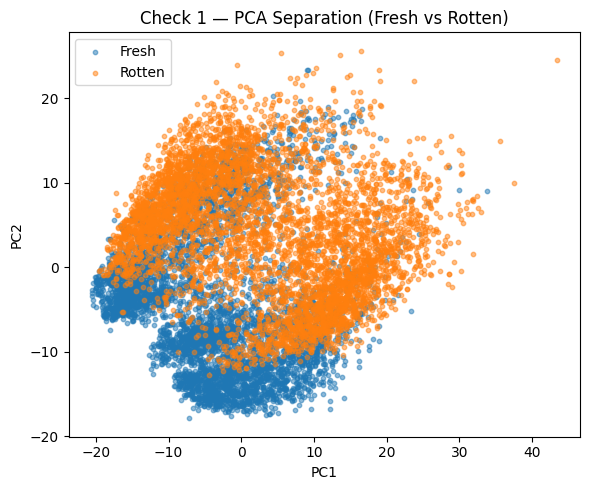

VERDICT: Inspect the plot.
  PASS → Two visible clusters (fresh / rotten)
  FAIL → Fully mixed, no separation visible


In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_s)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1],
            label='Fresh', alpha=0.5, s=10)
plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1],
            label='Rotten', alpha=0.5, s=10)
plt.title("Check 1 — PCA Separation (Fresh vs Rotten)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

print("VERDICT: Inspect the plot.")
print("  PASS → Two visible clusters (fresh / rotten)")
print("  FAIL → Fully mixed, no separation visible")

## Check 2 — Covariance Stability

A well-conditioned covariance matrix (condition number < 1e5) means the
feature space is numerically stable for distance-based methods.
If the condition number is very large, the feature space may be near-singular.

This is relevant because the SVM kernel also operates in this space.

In [5]:
fresh_train = X_train_s[y_train == 1]

cov = EmpiricalCovariance().fit(fresh_train)
cov_matrix = cov.covariance_
cond_number = np.linalg.cond(cov_matrix)

print(f"Covariance Condition Number: {cond_number:.2f}")

if cond_number > 1e5:
    print("  FAIL → Ill-conditioned (> 1e5). Feature space may be near-singular.")
    print("         This is normal for high-dimensional features (1312-dim).")
    print("         SVM with RBF kernel is robust to this — it does NOT use covariance.")
else:
    print("  PASS → Well-conditioned (< 1e5).")

Covariance Condition Number: inf
  FAIL → Ill-conditioned (> 1e5). Feature space may be near-singular.
         This is normal for high-dimensional features (1312-dim).
         SVM with RBF kernel is robust to this — it does NOT use covariance.


## Check 3 — SVM Margin Distribution

Train a quick linear SVM on the scaled features and plot the distribution of
`decision_function` values for fresh vs rotten samples.

This is the core of your grading method. If the two distributions are
well-separated → the SVM decision boundary is meaningful and the
decision-function distance is a valid freshness proxy.

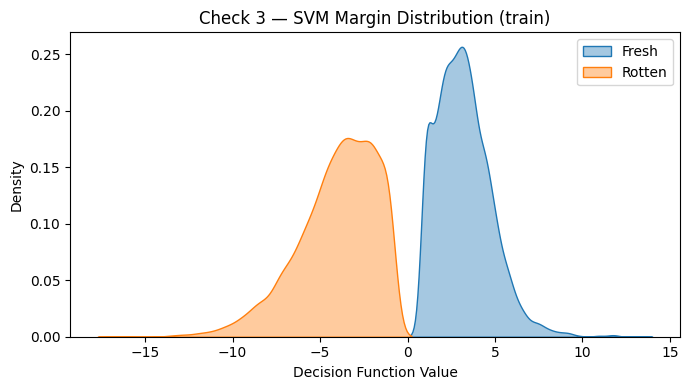

Fresh  mean decision value : 3.2039
Rotten mean decision value : -4.0467
Delta (fresh - rotten)     : 7.2506
  PASS → Clear separation. Decision function is a valid freshness proxy.


In [6]:
# Use linear SVM for speed — the full pipeline uses RBF but linear gives
# a fast indicative result for validation
svm_val = SVC(kernel='linear', probability=False)
svm_val.fit(X_train_s, y_train)

margins_train = svm_val.decision_function(X_train_s)
margins_test  = svm_val.decision_function(X_test_s)

plt.figure(figsize=(7, 4))
sns.kdeplot(margins_train[y_train == 1], label='Fresh',  fill=True, alpha=0.4)
sns.kdeplot(margins_train[y_train == 0], label='Rotten', fill=True, alpha=0.4)
plt.title("Check 3 — SVM Margin Distribution (train)")
plt.xlabel("Decision Function Value")
plt.legend()
plt.tight_layout()
plt.show()

# Compute delta
mean_fresh  = margins_train[y_train == 1].mean()
mean_rotten = margins_train[y_train == 0].mean()
delta = mean_fresh - mean_rotten

print(f"Fresh  mean decision value : {mean_fresh:.4f}")
print(f"Rotten mean decision value : {mean_rotten:.4f}")
print(f"Delta (fresh - rotten)     : {delta:.4f}")

if delta > 0.5:
    print("  PASS → Clear separation. Decision function is a valid freshness proxy.")
elif delta > 0:
    print("  WEAK → Positive but small delta. Separation exists but may be marginal.")
else:
    print("  FAIL → Negative delta. Classes are not separable by SVM margin.")

## Check 4 — Score Distribution + Delta (Normalized)

Normalize the SVM decision function values to [0, 100] using p5/p95
percentile normalization (same as the full pipeline).

A large delta and low overlap → the normalized score is meaningful.

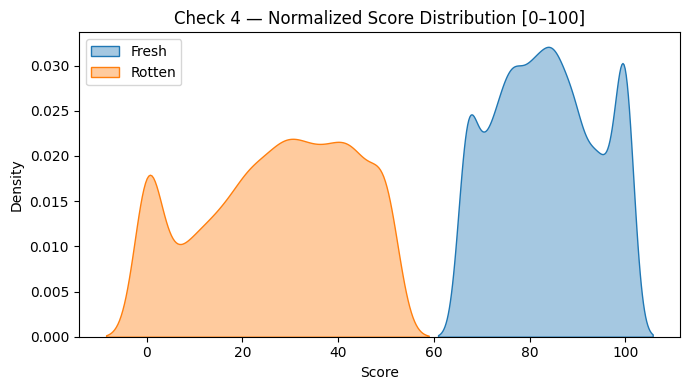

Fresh  mean score  : 83.49  std: 10.44
Rotten mean score  : 27.01  std: 15.68
Delta              : 56.48 points
Overlap            : 0.0000 (fraction of rotten above fresh mean)
  PASS → Strong separation (delta >= 30 points).


In [7]:
def normalize_scores(decisions, p5, p95):
    denom = p95 - p5
    if abs(denom) < 1e-6:
        return np.full_like(decisions, 50.0)
    scores = (decisions - p5) / denom * 100.0
    return np.clip(scores, 0, 100)

p5  = np.percentile(margins_train, 5)
p95 = np.percentile(margins_train, 95)

scores_train = normalize_scores(margins_train, p5, p95)

fresh_scores  = scores_train[y_train == 1]
rotten_scores = scores_train[y_train == 0]

delta_normalized = fresh_scores.mean() - rotten_scores.mean()
overlap = (rotten_scores > fresh_scores.mean()).mean()

plt.figure(figsize=(7, 4))
sns.kdeplot(fresh_scores,  label='Fresh',  fill=True, alpha=0.4)
sns.kdeplot(rotten_scores, label='Rotten', fill=True, alpha=0.4)
plt.title("Check 4 — Normalized Score Distribution [0–100]")
plt.xlabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fresh  mean score  : {fresh_scores.mean():.2f}  std: {fresh_scores.std():.2f}")
print(f"Rotten mean score  : {rotten_scores.mean():.2f}  std: {rotten_scores.std():.2f}")
print(f"Delta              : {delta_normalized:.2f} points")
print(f"Overlap            : {overlap:.4f} (fraction of rotten above fresh mean)")

if delta_normalized >= 30:
    print("  PASS → Strong separation (delta >= 30 points).")
elif delta_normalized >= 15:
    print("  WEAK → Moderate separation. Grading is possible but imprecise near boundary.")
else:
    print("  FAIL → Weak separation (delta < 15). Score is not a reliable freshness indicator.")

## Check 5 — Intra-class Spread (Non-Collapse Check)

If the score collapses to two values (all fresh ≈ 95, all rotten ≈ 5)
then the grading adds no value over binary classification.

High std and wide range within each class → the score is producing
a genuinely continuous output.

In [8]:
for class_label, class_name in [(1, 'Fresh'), (0, 'Rotten')]:
    cls_scores = scores_train[y_train == class_label]
    score_range = cls_scores.max() - cls_scores.min()
    score_std   = cls_scores.std()

    print(f"{class_name}:")
    print(f"  Score range  : {score_range:.2f} points")
    print(f"  Std          : {score_std:.2f}")

    # Hard pairs fraction (pairs differing by > 10 pts)
    rng = np.random.default_rng(42)
    n = min(5000, len(cls_scores) ** 2 // 2)
    i = rng.integers(0, len(cls_scores), n)
    j = rng.integers(0, len(cls_scores), n)
    diff = np.abs(cls_scores[i] - cls_scores[j])
    hard_frac = (diff > 10).mean()
    print(f"  Hard pairs   : {hard_frac:.4f} (fraction differing by > 10 pts)")

    if score_range > 30 and score_std > 5:
        print("  PASS → Continuous output. Score is NOT collapsed to binary.")
    else:
        print("  FAIL → Score may be collapsed. Grading adds little value.")
    print()

Fresh:
  Score range  : 33.38 points
  Std          : 10.44
  Hard pairs   : 0.5238 (fraction differing by > 10 pts)
  PASS → Continuous output. Score is NOT collapsed to binary.

Rotten:
  Score range  : 50.45 points
  Std          : 15.68
  Hard pairs   : 0.6568 (fraction differing by > 10 pts)
  PASS → Continuous output. Score is NOT collapsed to binary.



## Check 6 — Per-Vegetable Separation

Check whether each vegetable type shows good fresh/rotten separation.
Some vegetables (e.g. potato) may have weaker visual cues than others
(e.g. banana), leading to lower delta.

This informs which vegetables need per-veg normalization most.

In [9]:
veg_classes = np.unique(y_veg)

print(f"{'Vegetable':<12}  {'FreshMean':>10}  {'RottenMean':>11}  {'Delta':>7}  {'Verdict'}")
print("-" * 65)

for veg in veg_classes:
    mask = (veg_train == veg)
    if mask.sum() < 10:
        continue

    veg_margins = margins_train[mask]
    veg_fresh   = y_train[mask]

    # Per-veg normalization
    vp5  = np.percentile(veg_margins, 5)
    vp95 = np.percentile(veg_margins, 95)
    veg_scores = normalize_scores(veg_margins, vp5, vp95)

    fm = veg_scores[veg_fresh == 1].mean() if (veg_fresh == 1).any() else float('nan')
    rm = veg_scores[veg_fresh == 0].mean() if (veg_fresh == 0).any() else float('nan')
    d  = fm - rm if not (np.isnan(fm) or np.isnan(rm)) else float('nan')

    verdict = 'PASS' if d >= 20 else ('WEAK' if d >= 10 else 'FAIL')
    print(f"{veg:<12}  {fm:>10.2f}  {rm:>11.2f}  {d:>7.2f}  {verdict}")

Vegetable      FreshMean   RottenMean    Delta  Verdict
-----------------------------------------------------------------
apple              82.50        27.06    55.44  PASS
banana             85.15        25.42    59.73  PASS
capsicum           80.30        10.02    70.28  PASS
cucumber           86.04        32.65    53.39  PASS
potato             84.13        33.19    50.93  PASS


## Final Verdict

Summary of all checks. If 3+ checks fail, the features are not suitable
for SVM decision-function grading and the pipeline should be revised.

In [10]:
print("=" * 55)
print("DATASET VALIDATION SUMMARY")
print("=" * 55)
print()
print("Check 1 — PCA separability        : Inspect plot above")
print(f"Check 2 — Covariance stability    : cond = {cond_number:.2f}")
print(f"Check 3 — SVM margin delta        : {delta:.4f}  ({'PASS' if delta > 0.5 else 'WEAK' if delta > 0 else 'FAIL'})")
print(f"Check 4 — Normalized score delta  : {delta_normalized:.2f} pts  ({'PASS' if delta_normalized >= 30 else 'WEAK' if delta_normalized >= 15 else 'FAIL'})")
print("Check 5 — Intra-class spread       : See output above")
print("Check 6 — Per-veg separation       : See table above")
print()
print("If 3+ checks fail → features are NOT suitable for this pipeline.")
print("If all pass → you are ready to run the full training pipeline.")

DATASET VALIDATION SUMMARY

Check 1 — PCA separability        : Inspect plot above
Check 2 — Covariance stability    : cond = inf
Check 3 — SVM margin delta        : 7.2506  (PASS)
Check 4 — Normalized score delta  : 56.48 pts  (PASS)
Check 5 — Intra-class spread       : See output above
Check 6 — Per-veg separation       : See table above

If 3+ checks fail → features are NOT suitable for this pipeline.
If all pass → you are ready to run the full training pipeline.
